In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv('../cyberbullying_datasets/course_dataset/cb_chi_compressed.csv.gz')
df.head()

,idiot,stupid,moron,dumb,fuck,love,xa,comment,shut,fool,...,blue cheese,suck bitach,bitach,follow jackass,jackass hate,free publicity,publicity,miss idiot,village miss,bullying
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(['bullying'], axis=1), df['bullying'], 
                                                    test_size=.3, random_state=0, stratify=df['bullying'])

In [15]:
grid = {
    'max_depth': [90, 100, 130],
    'min_samples_split': [2],
    'min_samples_leaf': [5, 10, 50],
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=0), grid, cv=3, scoring='accuracy').fit(X_train, y_train)

In [16]:
grid_search.best_params_

{'max_depth': 90, 'min_samples_leaf': 10, 'min_samples_split': 2}

In [17]:
print(grid_search.best_estimator_.score(X_test, y_test))
print(grid_search.best_estimator_.score(X_train, y_train))

0.6585365853658537
0.7290913784202375


In [18]:
print(classification_report(y_test, grid_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.62      0.80      0.70      1657
           1       0.72      0.52      0.60      1664

    accuracy                           0.66      3321
   macro avg       0.67      0.66      0.65      3321
weighted avg       0.67      0.66      0.65      3321



In [ ]:
dtc = DecisionTreeClassifier(
    max_depth=90, 
    min_samples_split=2,
    min_samples_leaf=10, 
    random_state=0
).fit(X_train, y_train)

In [5]:
print(classification_report(y_test, dtc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.65      0.58      0.62      1657
           1       0.62      0.70      0.66      1664

    accuracy                           0.64      3321
   macro avg       0.64      0.64      0.64      3321
weighted avg       0.64      0.64      0.64      3321



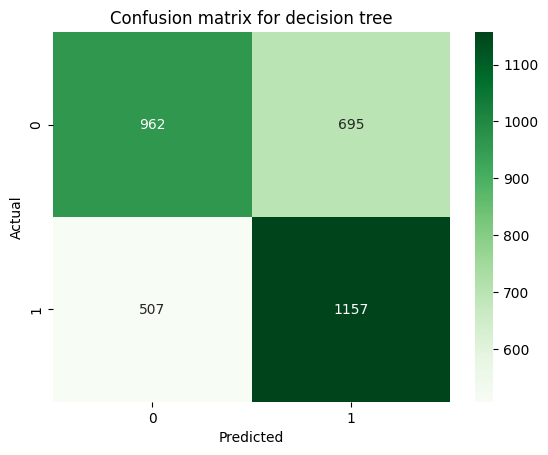

In [17]:
from seaborn import heatmap
from sklearn.metrics import confusion_matrix
test_pred = dtc.predict(X_test)

fig, ax = plt.subplots(1, 1)
heatmap(confusion_matrix(y_test, test_pred), annot = True, fmt = 'd', cmap = 'Greens', ax = ax)
ax.set_title('Confusion matrix for decision tree')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

In [60]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=0, max_depth=3, min_samples_leaf=70, min_samples_split=2),
    n_estimators=100,
    random_state=0
).fit(X_train, y_train)

In [61]:
model.score(X_test, y_test)

0.639867509786209

In [62]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.65      0.61      0.63      1657
           1       0.63      0.67      0.65      1664

    accuracy                           0.64      3321
   macro avg       0.64      0.64      0.64      3321
weighted avg       0.64      0.64      0.64      3321



In [134]:
def factorial(n):
    return np.prod([i for i in range(2, n + 1)])

def f(x): return np.cos(x)

def diff_f(n, x):
    a = -1 if n % 4 in (1, 2) else 1
        
    if n % 2 == 0:
        return a * np.cos(x)
    return a * np.sin(x)

In [135]:
def taylor(n, a, x):
    return sum([(diff_f(i, a) * (x - a) ** i) / factorial(i) for i in range(n + 1)])

In [136]:
def error_pct(exact, estimated):
    print(f'{(estimated - exact) / exact:.10%}')

In [151]:
error_pct(f(0.2), taylor(2, 0, 0.2))

-0.0067931958%
